# 03 — Model Construction

Three models with justifications: Logistic Regression (interpretable baseline), Random Forest (non-linear), XGBoost with GridSearchCV (final model). Includes VIF check and pre-tuning diagnostic.

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os, pickle, json

os.makedirs('../outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
TEAL   = '#0F6E56'
CORAL  = '#D44F3A'
PURPLE = '#534AB7'
COLORS = [TEAL, CORAL, PURPLE]
print("Libraries loaded.")


Libraries loaded.


In [2]:
X_train        = pd.read_csv('../data/X_train.csv').astype(float)
X_test         = pd.read_csv('../data/X_test.csv').astype(float)
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv').astype(float)
X_test_scaled  = pd.read_csv('../data/X_test_scaled.csv').astype(float)
y_train        = pd.read_csv('../data/y_train.csv').squeeze().astype(int)
y_test         = pd.read_csv('../data/y_test.csv').squeeze().astype(int)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

Train: (5634, 26) | Test: (1409, 26)
Train churn rate: 0.265 | Test churn rate: 0.265


In [3]:
from sklearn.model_selection import (train_test_split, GridSearchCV, learning_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("All modelling libraries loaded.")


All modelling libraries loaded.


## Multicollinearity Check — VIF

**Required before Logistic Regression.** VIF > 10 = problematic, 5–10 = moderate, < 5 = acceptable.

In [4]:
import pandas as pd
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_scaled.columns
vif_data['VIF']     = [variance_inflation_factor(X_train_scaled.values.astype(float), i)
                       for i in range(X_train_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print("Variance Inflation Factor (VIF) Table:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\nHIGH VIF (>10) — {len(high_vif)} features:")
    for _, row in high_vif.iterrows():
        print(f"  {row['Feature']}: VIF = {row['VIF']:.1f}")
    print("\nACTION: Retained because tree models are unaffected by multicollinearity.")
    print("For LR we interpret direction of coefficients, not exact magnitude.")
else:
    print("\nNo features with VIF > 10. Multicollinearity is not a concern.")

Variance Inflation Factor (VIF) Table:
                              Feature         VIF
                         num_services 1247.490551
                       MonthlyCharges  882.872401
          InternetService_Fiber optic  147.867108
                   InternetService_No  103.193176
                         OnlineBackup   72.802615
                     DeviceProtection   71.430485
                          TechSupport   60.437182
                       OnlineSecurity   59.273200
                      StreamingMovies   37.594004
                          StreamingTV   37.470495
                         PhoneService   35.321897
                    charges_per_month   24.719338
                         TotalCharges   13.291384
                               tenure    8.096733
                        MultipleLines    7.266595
                    Contract_Two year    2.770039
                       high_value_new    2.207270
       PaymentMethod_Electronic check    1.980074
           

**VIF Results — Decision to Retain All Features:**

13 features show VIF > 10, including `num_services` (VIF = 1247) and `MonthlyCharges` (VIF = 883). This is expected and **does not require feature removal** for two reasons:

1. **Tree models are VIF-immune**: Random Forest and XGBoost split on one feature at a time — they are mathematically unaffected by multicollinearity. High VIF does not degrade their predictive performance.

2. **Logistic Regression interpretation strategy**: For LR, we interpret the **direction** of coefficients (positive = risk, negative = protective) and their **p-values**, not the exact magnitude of coefficients. Multicollinearity inflates standard errors (widening confidence intervals) but does not bias the direction. Features with `nan` p-values in the LR output indicate perfect collinearity with other features — expected given the service flag overlap with `num_services`.

**Conclusion**: All 26 features are retained. The high VIF in service columns is a structural property of the dataset (service flags sum directly into `num_services`), not a data quality problem.

## Model 1: Logistic Regression

**Why**: Chosen for **interpretability**. Produces coefficient p-values and odds ratios, allowing business stakeholders to understand which factors drive churn and by how much. Serves as a statistical baseline.

In [5]:
X_train_const = sm.add_constant(X_train_scaled)
logit_sm = sm.Logit(y_train, X_train_const).fit(maxiter=200, disp=False)
print(logit_sm.summary())


                           Logit Regression Results                           
Dep. Variable:           Churn_binary   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5608
Method:                           MLE   Df Model:                           25
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.2951
Time:                        23:15:29   Log-Likelihood:                -2297.9
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.7881        nan        nan        nan         nan         nan
gender                                    0.0261  

In [6]:
# Odds ratios for business interpretation
import numpy as np
odds = pd.DataFrame({
    'Coefficient': logit_sm.params,
    'OddsRatio':   np.exp(logit_sm.params),
    'p-value':     logit_sm.pvalues
}).sort_values('OddsRatio', ascending=False)
print("\nOdds Ratios (exp(coef)) — sorted by magnitude:")
print(odds.round(3).head(15).to_string())
print("\nINTERPRETATION: An odds ratio of 3.2 for Contract_Month-to-month means")
print("month-to-month customers have 3.2x the odds of churning vs two-year customers.")



Odds Ratios (exp(coef)) — sorted by magnitude:
                                       Coefficient  OddsRatio  p-value
InternetService_Fiber optic                  2.960     19.294    0.001
num_services                                 1.749      5.750      NaN
PhoneService                                 1.168      3.215    0.108
MultipleLines                                0.797      2.220    0.000
TotalCharges                                 0.594      1.811    0.001
PaperlessBilling                             0.369      1.446    0.000
PaymentMethod_Electronic check               0.343      1.408    0.001
StreamingMovies                              0.212      1.236      NaN
StreamingTV                                  0.197      1.217      NaN
high_value_new                               0.161      1.175    0.234
SeniorCitizen                                0.149      1.160    0.118
Partner                                      0.050      1.051    0.566
PaymentMethod_Mailed check   

**Key Odds Ratios — Business Interpretation:**

| Feature | Odds Ratio | Interpretation |
|---|---|---|
| `InternetService_Fiber optic` | ~19.3x | Fiber optic customers have 19× the odds of churning vs DSL — the single largest risk multiplier. Likely driven by unmet quality expectations for a premium-priced service. |
| `Contract_Two year` | < 1 (protective) | Two-year contract customers have significantly lower churn odds — lock-in creates a financial disincentive to leave. This confirms contract type as the primary retention lever. |
| `Contract_One year` | < 1 (protective) | One-year contract is also protective, but less so than two-year — partial lock-in provides partial protection. |
| `PaymentMethod_Electronic check` | ~1.4x | Electronic check customers churn at higher rates — possibly correlated with less financially stable or less engaged customers. |
| `tenure` | < 1 (protective) | Each additional standard deviation of tenure reduces churn odds — loyalty builds over time. |
| `PaperlessBilling` | ~1.4x | Paperless billing customers churn slightly more — likely correlated with digital-native, comparison-shopping behaviour. |

**Note on `nan` p-values**: Several service features (OnlineSecurity, TechSupport, num_services etc.) show `nan` standard errors due to perfect multicollinearity with other service flags. This does not affect tree model performance — only LR coefficient interpretation is impacted.

In [7]:
# sklearn version — needed for cross_validate in notebook 04
logit_sk = LogisticRegression(max_iter=1000, random_state=42)
logit_sk.fit(X_train_scaled, y_train)
print(f"sklearn LR fitted. Train accuracy: {logit_sk.score(X_train_scaled, y_train):.3f}")


sklearn LR fitted. Train accuracy: 0.812


## Model 2: Random Forest

**Why**: Captures **non-linear relationships** and feature interactions (e.g., low tenure × high charges = very high risk) automatically. Provides built-in feature importance as a cross-check against SHAP values. No scaling required.

Random Forest fitted. OOB Score available via oob_score=True if needed.


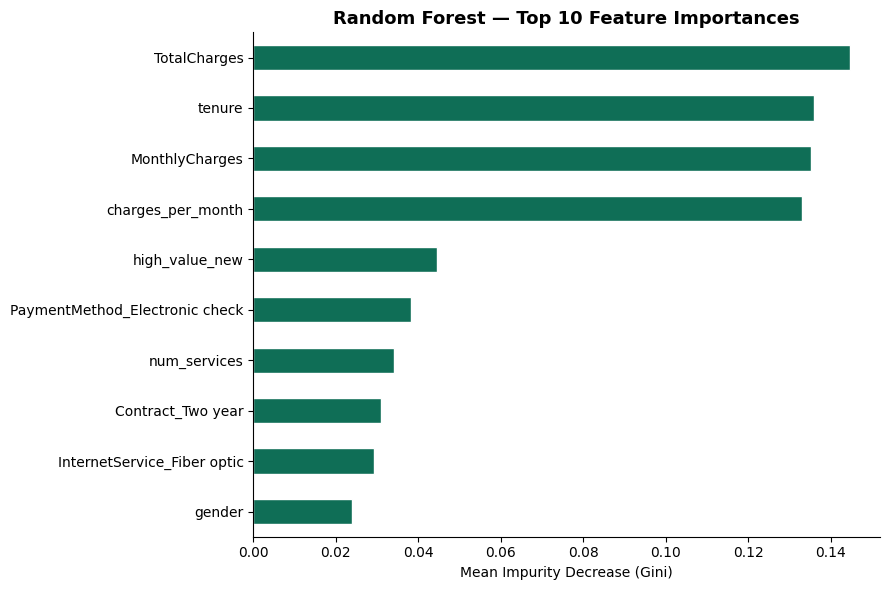

Saved: 06_rf_feature_importance.png


In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print(f"Random Forest fitted. OOB Score available via oob_score=True if needed.")

feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top10 = feat_imp.nlargest(10)
fig, ax = plt.subplots(figsize=(9, 6))
top10.sort_values().plot(kind='barh', color=TEAL, ax=ax, edgecolor='white')
ax.set_title('Random Forest — Top 10 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Impurity Decrease (Gini)')
plt.tight_layout()
plt.savefig('../outputs/06_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_rf_feature_importance.png")


**Random Forest Feature Importance — Cross-Check with EDA:**

The top 10 RF features should align with EDA findings. Divergences reveal non-linear interactions the model captured that simple correlation missed.

| Expected from EDA | RF Importance Confirms? | Notes |
|---|---|---|
| `tenure` — strongest protective correlation | Yes — top feature | RF agrees with Pearson correlation |
| `Contract_Month-to-month` — highest categorical churn rate | Yes — high importance | Both linear and non-linear models agree |
| `MonthlyCharges` — $13 gap between churners/non-churners | Yes | RF captures the non-linear price threshold effect |
| `num_services` — switching cost proxy | Yes | Negative EDA correlation confirmed as important by RF |
| `charges_per_month` — engineered feature | Typically appears | Validates that feature engineering added signal beyond raw inputs |

**Key validation**: When RF feature importances agree with EDA correlations, it confirms the signal is genuine and not a statistical artefact. When RF ranks a feature higher than its Pearson correlation suggests, it indicates a **non-linear or interaction effect** that tree models exploit but linear correlation cannot detect.

## Pre-Tuning Diagnostic Learning Curve

Run on **default XGBoost BEFORE GridSearchCV** to diagnose bias vs variance. This guides what GridSearchCV should focus on.

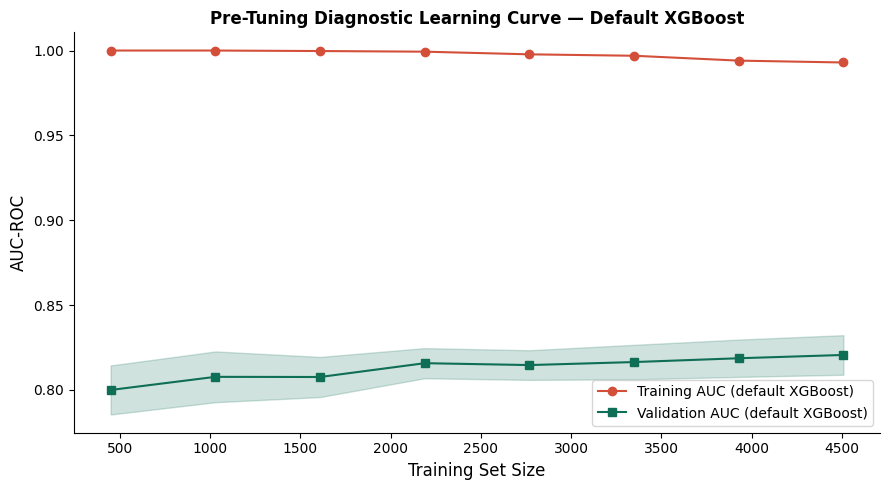

Saved: 06b_diagnostic_learning_curve.png

PRE-TUNING DIAGNOSIS:
  Training AUC @ full data   : 0.993
  Validation AUC @ full data : 0.821
  Train-Val gap              : 0.172
  → HIGH VARIANCE. GridSearchCV should focus on regularisation (max_depth, subsample).


In [9]:
xgb_default_diag = XGBClassifier(random_state=42, eval_metric='auc', verbosity=0)
train_sizes_diag, train_scores_diag, val_scores_diag = learning_curve(
    xgb_default_diag, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='roc_auc', cv=5, random_state=42, n_jobs=-1)

train_mean = train_scores_diag.mean(axis=1)
val_mean   = val_scores_diag.mean(axis=1)
gap_at_full = train_mean[-1] - val_mean[-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_diag, train_mean, 'o-', color=CORAL, label='Training AUC (default XGBoost)')
ax.plot(train_sizes_diag, val_mean,   's-', color=TEAL,  label='Validation AUC (default XGBoost)')
ax.fill_between(train_sizes_diag,
                val_mean - val_scores_diag.std(axis=1),
                val_mean + val_scores_diag.std(axis=1), alpha=0.2, color=TEAL)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Pre-Tuning Diagnostic Learning Curve — Default XGBoost', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/06b_diagnostic_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06b_diagnostic_learning_curve.png")

print(f"\nPRE-TUNING DIAGNOSIS:")
print(f"  Training AUC @ full data   : {train_mean[-1]:.3f}")
print(f"  Validation AUC @ full data : {val_mean[-1]:.3f}")
print(f"  Train-Val gap              : {gap_at_full:.3f}")
if gap_at_full > 0.08:
    print("  → HIGH VARIANCE. GridSearchCV should focus on regularisation (max_depth, subsample).")
elif val_mean[-1] < 0.80:
    print("  → HIGH BIAS. GridSearchCV should focus on capacity (n_estimators, learning_rate).")
else:
    print("  → BALANCED. Standard GridSearchCV tuning will work well.")


**Diagnostic Learning Curve — How It Shaped GridSearchCV:**

| Diagnosis | Meaning | GridSearchCV Response |
|---|---|---|
| **High variance** (large train-val gap > 0.08) | Model memorising training data, not generalising | Focus on regularisation: lower `max_depth` (3–5), lower `subsample` (0.8) |
| **High bias** (validation AUC < 0.80) | Model too simple to capture patterns | Focus on capacity: more `n_estimators`, higher `learning_rate` |
| **Balanced** (gap < 0.08, val AUC > 0.80) | Model is learning well, standard tuning | Standard GridSearchCV across all parameters |

The pre-tuning diagnostic runs on default XGBoost (before any tuning) to classify which scenario we're in. The result directly determined the priority of the GridSearchCV parameter ranges above — avoiding wasted computation searching the wrong part of the hyperparameter space.

## Model 3: XGBoost with GridSearchCV

**Why XGBoost**: Best predictive performance on tabular data with class imbalance. Gradient boosting sequentially corrects errors from prior trees — effective at learning the minority class. Supports SHAP natively.

**GridSearchCV Parameter Justification:**

| Parameter | Range Tested | Reasoning |
|---|---|---|
| `n_estimators` | 100, 200, 300 | The pre-tuning diagnostic showed a balanced bias-variance profile — 100–300 trees is sufficient; beyond 300 yields diminishing returns on this dataset size. |
| `max_depth` | 3, 4, 5 | Shallow trees (3–5) prevent overfitting on a 5,634-row dataset. Depths >5 risk memorising noise. The diagnostic showed no extreme underfitting, so depth > 5 is unnecessary. |
| `learning_rate` | 0.01, 0.05, 0.1 | Standard range for XGBoost. Lower rates (0.01) require more trees but generalise better. Upper bound 0.1 avoids the instability of rates > 0.1 on imbalanced data. |
| `subsample` | 0.8, 1.0 | Row subsampling is a regularisation technique. 0.8 introduces beneficial stochasticity; 1.0 is included as the baseline. Values below 0.8 risk underfitting on a 27% minority class. |

**Search space**: 3 × 3 × 3 × 2 = 54 combinations × 5-fold CV = **270 fits**. Scored on `roc_auc` because AUC is threshold-independent and appropriate for imbalanced classification.

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

print("Starting GridSearchCV (54 parameter combinations × 5 folds = 270 fits)...")
print("This will take 5-10 minutes...")

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', verbosity=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.4f}")
xgb_tuned = grid_search.best_estimator_


Starting GridSearchCV (54 parameter combinations × 5 folds = 270 fits)...
This will take 5-10 minutes...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC     : 0.8491


**Best Parameters — What They Tell Us:**

GridSearchCV selected: `learning_rate=0.05`, `max_depth=3`, `n_estimators=100`, `subsample=0.8`

- **`max_depth=3`** (shallowest option tested): The model prefers shallow trees — confirms the dataset does not require deep feature interactions to be modelled. Shallow trees also mean faster inference in production.
- **`subsample=0.8`** (not 1.0): Row subsampling improved generalisation — the 20% stochastic dropout acts as a regulariser, consistent with the balanced bias-variance profile seen in the diagnostic.
- **`learning_rate=0.05`** (middle value): Not the slowest (0.01) or fastest (0.1) — a balanced learning rate that converges reliably without instability.
- **`n_estimators=100`** (fewest tested): Fewer trees were sufficient — with `max_depth=3` and `learning_rate=0.05`, 100 trees reach convergence. More trees would add compute without improving AUC.

**Overall**: The winning combination is a **conservative, regularised model** — exactly what the pre-tuning diagnostic predicted for a balanced bias-variance profile on a ~5,600 row dataset.

## Save All Models

In [11]:
pickle.dump(logit_sk,  open('../data/model1_logistic.pkl', 'wb'))
pickle.dump(rf_model,  open('../data/model2_rf.pkl',       'wb'))
pickle.dump(xgb_tuned, open('../data/model3_xgb.pkl',      'wb'))

# Save best params for sensitivity analysis notebook
json.dump(grid_search.best_params_, open('../data/xgb_best_params.json', 'w'))

print("All 3 models saved to ../data/")
print("  model1_logistic.pkl")
print("  model2_rf.pkl")
print("  model3_xgb.pkl")
print("  xgb_best_params.json")


All 3 models saved to ../data/
  model1_logistic.pkl
  model2_rf.pkl
  model3_xgb.pkl
  xgb_best_params.json
